# Module 5: HRRR Real-Time Ingestion Pipeline
## HyperWind-Now | Physics-Constrained ML for Low-Altitude Urban Wind Forecasting over DFW

---

### Motivation

Modules 1–4 demonstrated the full nowcasting + physics-constraint + EnKF pipeline using **ERA5 reanalysis** as the background field. ERA5 is ideal for offline development but is a *reanalysis* product with a delay of several months — it cannot power real-time drone flight decisions.

**HRRR (High-Resolution Rapid Refresh)** is NOAA's operational convection-allowing model:
- **3 km horizontal resolution** (vs. ~28 km for ERA5 over this domain)
- **Hourly initialization cycle** — new forecasts every 60 minutes
- **18-hour forecast horizon** (48 hours at 00/06/12/18 UTC)
- **Radar assimilation every 15 min** — captures rapidly-evolving convection
- **Freely available** on AWS S3 (`s3://noaa-hrrr-bdp-pds`) — no credentials required

This module builds a production-grade ingestion pipeline:
1. Fetch HRRR GRIB2 subsets from AWS S3 via **Herbie** (byte-range requests, ~2-5 MB vs 150 MB full file)
2. Reproject from HRRR Lambert Conformal Conic grid to ERA5-compatible 0.25 lat/lon
3. Apply QC checks (physical bounds, NaN fraction, gradient artifacts)
4. Export to drop-in NetCDF matching the ERA5 schema consumed by Modules 1-4

```
HRRR (AWS S3, 3km, hourly) + ASOS Observations
              down
  Module 5: HRRR Ingestion Pipeline  <- THIS NOTEBOOK
  (fetch -> reproject -> QC -> NetCDF)
              down
  Module 1: Feature Engineering      (unchanged)
              down
  Module 2: TrajGRU Nowcasting       (unchanged)
              down
  Module 3: Physics Constraint Layer (unchanged)
              down
  Module 4: EnKF Data Assimilation   (unchanged)
              down
  CLEAR TO FLY / NO-FLY alert
```

### Domain
| Parameter | Value |
|---|---|
| Latitude | 32.25 - 33.25 N |
| Longitude | 97.75 - 96.50 W |
| Pressure levels | 1000, 975, 950 hPa |
| Output resolution | 0.25 lat/lon (5x6 grid, matching ERA5) |
| ASOS stations | DFW, DAL, FTW, AFW, DTO, RBD |

## 5.0 | Environment Setup

In [25]:
# Install dependencies into the active kernel (run once if needed)
import sys
# !{sys.executable} -m pip install herbie-data cfgrib scipy pyproj eccodes

In [26]:
import warnings
warnings.filterwarnings('ignore')

import sys, time, json, logging
from pathlib import Path
from datetime import datetime, timedelta, timezone
from typing import Optional, List, Dict, Tuple

import numpy as np
import pandas as pd
import xarray as xr
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt

from herbie import Herbie

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
log = logging.getLogger('hyperwind.module5')

print('Environment loaded successfully.')

Environment loaded successfully.


## 5.1 | Domain & Variable Configuration

In [27]:
# DFW domain - identical to Modules 1-4 for drop-in compatibility
DOMAIN = {
    'lat_min': 32.25, 'lat_max': 33.25,
    'lon_min': -97.75, 'lon_max': -96.50,
    'lat_res': 0.25, 'lon_res': 0.25,
}

OUT_LATS = np.arange(DOMAIN['lat_min'], DOMAIN['lat_max'] + 1e-9, DOMAIN['lat_res'])
OUT_LONS = np.arange(DOMAIN['lon_min'], DOMAIN['lon_max'] + 1e-9, DOMAIN['lon_res'])

# HRRR GRIB2 variable search strings matched against the inventory.
# Important: HRRR sfc product uses 'MSLMA' for MSLP, not 'PRMSL'.
HRRR_SFC_SEARCH = '|'.join([
    ':UGRD:10 m above ground:',
    ':VGRD:10 m above ground:',
    ':GUST:surface:',
    ':TMP:2 m above ground:',
    ':MSLMA:',
])

HRRR_PRS_SEARCH = '|'.join([
    ':UGRD:1000 mb:',
    ':VGRD:1000 mb:',
    ':UGRD:975 mb:',
    ':VGRD:975 mb:',
    ':UGRD:950 mb:',
    ':VGRD:950 mb:',
])

ASOS_STATIONS = {
    'DFW': {'lat': 32.897, 'lon': -97.038},
    'DAL': {'lat': 32.847, 'lon': -96.852},
    'FTW': {'lat': 32.820, 'lon': -97.362},
    'AFW': {'lat': 32.988, 'lon': -97.318},
    'DTO': {'lat': 33.201, 'lon': -97.198},
    'RBD': {'lat': 32.681, 'lon': -96.868},
}

DATA_DIR    = Path('../data')
RAW_DIR     = DATA_DIR / 'hrrr_raw'
PROC_DIR    = DATA_DIR / 'processed'
RESULTS_DIR = Path('../results')
for d in [RAW_DIR, PROC_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Output grid: {len(OUT_LATS)} lat x {len(OUT_LONS)} lon')
print(f'Lat: {OUT_LATS[0]:.2f} to {OUT_LATS[-1]:.2f}')
print(f'Lon: {OUT_LONS[0]:.2f} to {OUT_LONS[-1]:.2f}')

Output grid: 5 lat x 6 lon
Lat: 32.25 to 33.25
Lon: -97.75 to -96.50


## 5.2 | Inventory Probe

Inspect the actual HRRR GRIB2 inventory before running the pipeline.
This confirms which variable names are available and catches naming differences
between HRRR product versions.

In [28]:
PROBE_CYCLE = datetime(2021, 4, 6, 21, 0, 0)

print(f'Probing HRRR inventory: {PROBE_CYCLE:%Y-%m-%d %H:%M} UTC')
print()

for product in ['sfc', 'prs']:
    try:
        H = Herbie(
            PROBE_CYCLE.strftime('%Y-%m-%d %H:%M'),
            model='hrrr', product=product, fxx=0, verbose=False
        )
        inv = H.inventory()
        mask = inv['search_this'].str.contains(
            'UGRD|VGRD|GUST|TMP|MSL|PRMSL|MSLMA', case=False, na=False
        )
        subset = inv[mask][['search_this', 'variable', 'level']].head(20)
        print(f'--- product={product} ---')
        print(subset.to_string(index=False))
        print()
    except Exception as e:
        print(f'Could not probe {product}: {e}')

Probing HRRR inventory: 2021-04-06 21:00 UTC

--- product=sfc ---
       search_this variable   level
:GUST:surface:anl:     GUST surface
 :UGRD:250 mb:anl:     UGRD  250 mb
 :VGRD:250 mb:anl:     VGRD  250 mb
 :UGRD:300 mb:anl:     UGRD  300 mb
 :VGRD:300 mb:anl:     VGRD  300 mb
  :TMP:500 mb:anl:      TMP  500 mb
 :UGRD:500 mb:anl:     UGRD  500 mb
 :VGRD:500 mb:anl:     VGRD  500 mb
  :TMP:700 mb:anl:      TMP  700 mb
 :UGRD:700 mb:anl:     UGRD  700 mb
 :VGRD:700 mb:anl:     VGRD  700 mb
  :TMP:850 mb:anl:      TMP  850 mb
 :UGRD:850 mb:anl:     UGRD  850 mb
 :VGRD:850 mb:anl:     VGRD  850 mb
  :TMP:925 mb:anl:      TMP  925 mb
 :UGRD:925 mb:anl:     UGRD  925 mb
 :VGRD:925 mb:anl:     VGRD  925 mb
 :TMP:1000 mb:anl:      TMP 1000 mb
:UGRD:1000 mb:anl:     UGRD 1000 mb
:VGRD:1000 mb:anl:     VGRD 1000 mb

--- product=prs ---
      search_this variable  level
  :TMP:50 mb:anl:      TMP  50 mb
 :UGRD:50 mb:anl:     UGRD  50 mb
 :VGRD:50 mb:anl:     VGRD  50 mb
  :TMP:75 mb:anl:    

## 5.3 | HRRR Fetch Engine

In [29]:
class HRRRFetchEngine:
    """
    Fetches HRRR GRIB2 subsets from AWS S3 via Herbie byte-range requests.
    Only transfers the specific GRIB messages requested (~2-5 MB vs 150 MB).
    No AWS credentials required.
    """

    S3_BUCKET = 'noaa-hrrr-bdp-pds'

    def __init__(self, save_dir: Path = RAW_DIR):
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)

    def latest_available_cycle(self) -> datetime:
        """Return UTC datetime of most recent HRRR cycle likely on S3 (~50 min latency)."""
        now = datetime.now(timezone.utc).replace(tzinfo=None)
        cycle = now.replace(minute=0, second=0, microsecond=0) - timedelta(hours=1)
        log.info(f'Latest candidate cycle: {cycle:%Y-%m-%d %H:%M} UTC')
        return cycle

    def fetch_cycle(
        self,
        cycle_dt: datetime,
        fxx: int = 0,
        max_retries: int = 3,
    ) -> Optional[xr.Dataset]:
        """
        Fetch one HRRR cycle. Returns merged xr.Dataset or None if unavailable.
        """
        log.info(f'Fetching HRRR {cycle_dt:%Y-%m-%d %H:%M} UTC F{fxx:02d}')

        sfc_ds = self._fetch_product(cycle_dt, fxx, 'sfc', HRRR_SFC_SEARCH, max_retries)
        if sfc_ds is None:
            log.error('Failed to fetch sfc product')
            return None

        prs_ds = self._fetch_product(cycle_dt, fxx, 'prs', HRRR_PRS_SEARCH, max_retries)
        if prs_ds is None:
            log.error('Failed to fetch prs product')
            return None

        sfc_ds = self._rename_sfc(sfc_ds)
        prs_ds = self._rename_prs(prs_ds)

        merged = xr.merge([sfc_ds, prs_ds], compat='override')
        merged.attrs.update({
            'source':        'HRRR',
            'cycle':         cycle_dt.strftime('%Y-%m-%dT%H:%M:%SZ'),
            'fxx':           fxx,
            'valid_time':    (cycle_dt + timedelta(hours=fxx)).strftime('%Y-%m-%dT%H:%M:%SZ'),
            'resolution_km': 3,
            'pipeline':      'HyperWind-Now Module 5',
        })
        log.info(f'Fetched variables: {list(merged.data_vars)}')
        return merged

    def _fetch_product(
        self, cycle_dt, fxx, product, search, max_retries
    ) -> Optional[xr.Dataset]:
        for attempt in range(max_retries):
            try:
                H = Herbie(
                    cycle_dt.strftime('%Y-%m-%d %H:%M'),
                    model='hrrr', product=product, fxx=fxx,
                    save_dir=str(self.save_dir), verbose=False,
                )
                ds = H.xarray(search, remove_grib=True)
                if isinstance(ds, list):
                    ds = xr.merge(ds, compat='override')
                return ds
            except Exception as e:
                log.warning(f'Attempt {attempt+1}/{max_retries} ({product}): {e}')
                if attempt < max_retries - 1:
                    time.sleep(2 ** attempt)
        return None

    def _rename_sfc(self, ds: xr.Dataset) -> xr.Dataset:
        """
        Map cfgrib ECMWF shortNames to clean pipeline names.
        Checks GRIB_shortName, GRIB_name, and variable name itself.
        """
        rename = {}
        for v in list(ds.data_vars):
            attrs     = ds[v].attrs
            short     = str(attrs.get('GRIB_shortName', '')).lower()
            name      = str(attrs.get('GRIB_name', '')).lower()
            type_lev  = str(attrs.get('GRIB_typeOfLevel', '')).lower()
            lev_val   = attrs.get('GRIB_level', None)
            vl        = v.lower()

            if short == '10u' or (short in ('u', 'ugrd') and lev_val == 10):
                rename[v] = 'u10'
            elif short == '10v' or (short in ('v', 'vgrd') and lev_val == 10):
                rename[v] = 'v10'
            elif short == '2t' or (short == 'tmp' and lev_val == 2):
                rename[v] = 't2m'
            elif 'gust' in short or 'gust' in name or 'gust' in vl:
                rename[v] = 'gust'
            elif short in ('msl', 'prmsl', 'mslma') or 'mslma' in vl or 'prmsl' in vl:
                rename[v] = 'msl'

        if rename:
            ds = ds.rename({k: nv for k, nv in rename.items() if k in ds.data_vars})
        return ds

    def _rename_prs(self, ds: xr.Dataset) -> xr.Dataset:
        """
        Unstack cfgrib pressure-level winds into u1000, v1000, u975, v975, u950, v950.
        cfgrib returns u(isobaricInhPa, y, x) and v(isobaricInhPa, y, x).
        """
        out = {}
        for v in list(ds.data_vars):
            arr      = ds[v]
            short    = str(arr.attrs.get('GRIB_shortName', '')).lower()
            is_u     = short in ('u', 'ugrd') or v.lower().startswith('u')
            is_v     = short in ('v', 'vgrd') or v.lower().startswith('v')

            # Find the pressure-level dimension
            level_dim = None
            for dim in arr.dims:
                if 'isobar' in dim.lower() or dim in ('level', 'isobaricInhPa', 'pressure'):
                    level_dim = dim
                    break

            if level_dim is not None:
                for i, lev in enumerate(arr.coords[level_dim].values):
                    lev_int = int(lev)
                    if lev_int in [1000, 975, 950]:
                        prefix = 'u' if is_u else 'v'
                        key    = f'{prefix}{lev_int}'
                        # Slice and drop the level coordinate
                        sliced = arr.isel({level_dim: i})
                        drop   = [c for c in sliced.coords
                                  if level_dim in c or c == level_dim]
                        sliced = sliced.drop_vars(drop, errors='ignore')
                        out[key] = sliced

        return xr.Dataset(out, attrs=ds.attrs) if out else ds


engine = HRRRFetchEngine(save_dir=RAW_DIR)
print(f'HRRRFetchEngine ready.')
print(f'Latest candidate cycle: {engine.latest_available_cycle():%Y-%m-%d %H:%M} UTC')

2026-03-11 21:40:37 | INFO     | Latest candidate cycle: 2026-03-12 01:00 UTC


HRRRFetchEngine ready.
Latest candidate cycle: 2026-03-12 01:00 UTC


## 5.4 | Spatial Reprojection

HRRR uses Lambert Conformal Conic (LCC) on a 1059x1799 native grid.
We bilinearly interpolate to the 0.25 lat/lon output grid and apply a
grid-to-Earth wind rotation correction (alpha ~ 2-3 deg at DFW longitude).

In [30]:
class HRRRReprojector:
    """
    Reprojects HRRR native LCC grid to 0.25-degree lat/lon over the DFW domain.
    Applies LCC to Earth wind rotation correction for all U/V pairs.
    """

    BUFFER_DEG = 0.5
    LCC_LON_0  = -97.5   # HRRR CONUS central meridian
    LCC_LAT_0  =  38.5   # HRRR CONUS standard parallel
    WIND_PAIRS = [('u10', 'v10'), ('u1000', 'v1000'), ('u975', 'v975'), ('u950', 'v950')]

    def __init__(self, out_lats: np.ndarray, out_lons: np.ndarray):
        self.out_lats = out_lats
        self.out_lons = out_lons
        self.OUT_LON, self.OUT_LAT = np.meshgrid(out_lons, out_lats)

    def reproject(self, ds: xr.Dataset) -> xr.Dataset:
        """Reproject all variables in ds to the ERA5-compatible output grid."""
        hrrr_lat, hrrr_lon = self._get_latlon(ds)
        hrrr_lon = np.where(hrrr_lon > 180, hrrr_lon - 360, hrrr_lon)

        r0, r1, c0, c1 = self._crop_indices(hrrr_lat, hrrr_lon)
        sub_lat = hrrr_lat[r0:r1, c0:c1]
        sub_lon = hrrr_lon[r0:r1, c0:c1]

        # Wind rotation angles for this subdomain
        sub_rot = np.deg2rad(sub_lon - self.LCC_LON_0) * np.sin(np.deg2rad(self.LCC_LAT_0))
        rot_out = self._interp2d(sub_lat, sub_lon, sub_rot, self.OUT_LAT, self.OUT_LON)

        # Interpolate all 2D variables
        out_vars = {}
        for varname in list(ds.data_vars):
            data = ds[varname].values
            # Squeeze leading singleton dims added by cfgrib (time, step)
            while data.ndim > 2 and data.shape[0] == 1:
                data = data.squeeze(0)
            if data.ndim != 2:
                log.warning(f'Skipping {varname}: shape {data.shape} after squeeze')
                continue
            sub = data[r0:r1, c0:c1]
            out_vars[varname] = self._interp2d(sub_lat, sub_lon, sub,
                                               self.OUT_LAT, self.OUT_LON)

        # Apply grid-to-Earth wind rotation
        cos_a = np.cos(rot_out)
        sin_a = np.sin(rot_out)
        for u_name, v_name in self.WIND_PAIRS:
            if u_name in out_vars and v_name in out_vars:
                ug = out_vars[u_name].copy()
                vg = out_vars[v_name].copy()
                out_vars[u_name] = ug * cos_a - vg * sin_a
                out_vars[v_name] = ug * sin_a + vg * cos_a

        data_vars = {
            name: xr.DataArray(
                arr.astype(np.float32),
                dims=['latitude', 'longitude']
            )
            for name, arr in out_vars.items()
        }
        out_ds = xr.Dataset(
            data_vars,
            coords={
                'latitude':  ('latitude',  self.out_lats),
                'longitude': ('longitude', self.out_lons),
            },
            attrs={**ds.attrs, 'reprojection': 'bilinear LCC to 0.25deg lat/lon + wind rotation'}
        )
        log.info(f'Reprojected: {list(out_ds.data_vars)} -> {len(self.out_lats)}x{len(self.out_lons)}')
        return out_ds

    def _get_latlon(self, ds):
        for ln, lo in [('latitude','longitude'), ('lat','lon')]:
            if ln in ds.coords and lo in ds.coords:
                return ds.coords[ln].values, ds.coords[lo].values
        raise ValueError(f'No lat/lon coords found. Available: {list(ds.coords)}')

    def _crop_indices(self, lat, lon):
        b    = self.BUFFER_DEG
        mask = (
            (lat >= self.out_lats.min() - b) & (lat <= self.out_lats.max() + b) &
            (lon >= self.out_lons.min() - b) & (lon <= self.out_lons.max() + b)
        )
        if not mask.any():
            raise ValueError(
                f'No HRRR points found in DFW domain. '
                f'HRRR lat=[{lat.min():.1f},{lat.max():.1f}] '
                f'lon=[{lon.min():.1f},{lon.max():.1f}]'
            )
        rows, cols = np.where(mask)
        return rows.min(), rows.max() + 1, cols.min(), cols.max() + 1

    def _interp2d(self, src_lat, src_lon, src_data, dst_lat, dst_lon):
        lat_1d = np.mean(src_lat, axis=1)
        lon_1d = np.mean(src_lon, axis=0)
        si     = np.argsort(lat_1d)
        sj     = np.argsort(lon_1d)
        data_s = src_data[np.ix_(si, sj)].copy()
        lat_s  = lat_1d[si]
        lon_s  = lon_1d[sj]
        bad    = ~np.isfinite(data_s)
        if bad.any():
            data_s[bad] = np.nanmean(data_s)
        fn  = RegularGridInterpolator(
            (lat_s, lon_s), data_s,
            method='linear', bounds_error=False, fill_value=np.nan
        )
        pts = np.column_stack([dst_lat.ravel(), dst_lon.ravel()])
        return fn(pts).reshape(dst_lat.shape).astype(np.float32)


reprojector = HRRRReprojector(out_lats=OUT_LATS, out_lons=OUT_LONS)
print(f'HRRRReprojector ready. Output: {len(OUT_LATS)}x{len(OUT_LONS)} @ 0.25 deg')

HRRRReprojector ready. Output: 5x6 @ 0.25 deg


## 5.5 | Quality Control

In [31]:
class HRRRQualityControl:
    """
    Physical plausibility checks for HRRR-derived fields.
    Uses .data_vars throughout to avoid xarray coordinate/variable ambiguity.
    """

    BOUNDS = {
        'u10':   (-80,   80),
        'v10':   (-80,   80),
        'msl':   (87000, 108000),
        'gust':  (0,     120),
        't2m':   (220,   340),
        'u1000': (-80,   80),
        'v1000': (-80,   80),
        'u975':  (-100,  100),
        'v975':  (-100,  100),
        'u950':  (-100,  100),
        'v950':  (-100,  100),
    }

    MAX_NAN_FRACTION  = 0.05
    MAX_WIND_GRADIENT = 30.0

    def run(self, ds: xr.Dataset) -> Tuple[xr.Dataset, Dict]:
        """Run all QC checks. Returns (cleaned_ds, report dict)."""
        report = {'passed': True, 'warnings': [], 'failures': [], 'fixes': []}
        ds     = ds.copy(deep=True)

        for varname in list(ds.data_vars):
            data = ds[varname].values.astype(np.float64)

            # Check 1: NaN/Inf fraction
            bad  = ~np.isfinite(data)
            frac = float(bad.mean())
            if frac > self.MAX_NAN_FRACTION:
                report['failures'].append(
                    f'{varname}: {frac:.1%} non-finite (max {self.MAX_NAN_FRACTION:.0%})'
                )
                report['passed'] = False
            elif frac > 0:
                indices = distance_transform_edt(
                    bad, return_distances=False, return_indices=True
                )
                data = data[tuple(indices)]
                report['fixes'].append(f'{varname}: filled {int(bad.sum())} NaN cells')

            # Check 2: Physical bounds
            if varname in self.BOUNDS:
                lo, hi = self.BOUNDS[varname]
                n_bad  = int(np.sum((data < lo) | (data > hi)))
                if n_bad > 0:
                    f2  = n_bad / data.size
                    msg = f'{varname}: {n_bad} values outside [{lo},{hi}] ({f2:.2%})'
                    if f2 > 0.01:
                        report['failures'].append(msg)
                        report['passed'] = False
                    else:
                        data = np.clip(data, lo, hi)
                        report['fixes'].append(f'Clipped: {msg}')

            # Check 3: Wind gradient artifact check
            if varname in ('u10', 'v10') and data.ndim == 2:
                max_grad = max(
                    float(np.abs(np.diff(data, axis=0)).max()),
                    float(np.abs(np.diff(data, axis=1)).max())
                )
                if max_grad > self.MAX_WIND_GRADIENT:
                    report['warnings'].append(
                        f'{varname}: gradient {max_grad:.1f} m/s/cell - possible GRIB artifact'
                    )

            ds[varname] = xr.DataArray(
                data.astype(np.float32),
                dims=ds[varname].dims,
                coords=ds[varname].coords,
                attrs=ds[varname].attrs,
            )

        status           = 'PASS' if report['passed'] else 'FAIL'
        report['summary'] = (
            f"QC: {status} | {len(report['warnings'])} warnings | "
            f"{len(report['failures'])} failures | {len(report['fixes'])} fixes"
        )
        log.info(report['summary'])
        for w in report['warnings']:  log.warning(f'  QC WARNING: {w}')
        for f in report['failures']:  log.error(f'  QC FAILURE: {f}')
        return ds, report


qc = HRRRQualityControl()
print(f'HRRRQualityControl ready. Monitoring {len(qc.BOUNDS)} variables.')

HRRRQualityControl ready. Monitoring 11 variables.


## 5.6 | ERA5-Schema NetCDF Exporter

Output NetCDF matches Module 1 ERA5 schema exactly:
- Surface vars `u10`, `v10`, `msl` with dims `(time, latitude, longitude)`
- Pressure vars `u`, `v` with dims `(time, level, latitude, longitude)`
- Units: wind m/s, pressure Pa, temperature K
- Latitude descending (N to S)

In [32]:
class ERA5SchemaExporter:
    """
    Exports reprojected + QC'd HRRR data as an ERA5-schema NetCDF.
    All variable presence checks use .data_vars to avoid xarray KeyErrors.
    """

    ERA5_LAT_DESCENDING = True
    PRESSURE_LEVELS     = [1000, 975, 950]

    VAR_ATTRS = {
        'u10':  {'long_name': '10 metre U wind component', 'units': 'm s**-1'},
        'v10':  {'long_name': '10 metre V wind component', 'units': 'm s**-1'},
        'msl':  {'long_name': 'Mean sea level pressure',   'units': 'Pa'},
        'u':    {'long_name': 'U component of wind',       'units': 'm s**-1'},
        'v':    {'long_name': 'V component of wind',       'units': 'm s**-1'},
        'gust': {'long_name': 'Wind speed (gust)',          'units': 'm s**-1'},
        't2m':  {'long_name': '2 metre temperature',        'units': 'K'},
    }

    def export(
        self,
        ds: xr.Dataset,
        output_path: Path,
        valid_time: datetime,
    ) -> Path:

        lats = ds.coords['latitude'].values
        lons = ds.coords['longitude'].values

        # Latitude descending to match ERA5
        if self.ERA5_LAT_DESCENDING and lats[0] < lats[-1]:
            ds   = ds.isel(latitude=slice(None, None, -1))
            lats = ds.coords['latitude'].values

        time_coord = np.array([np.datetime64(valid_time, 'ns')])
        out_vars   = {}

        # Surface fields
        for v in ['u10', 'v10', 'msl', 'gust', 't2m']:
            if v in ds.data_vars:
                arr = ds[v].values
                out_vars[v] = xr.DataArray(
                    arr[np.newaxis].astype(np.float32),
                    dims=['time', 'latitude', 'longitude'],
                    attrs=self.VAR_ATTRS.get(v, {})
                )

        # Pressure-level fields - stack levels found in the dataset
        u_levs, v_levs, good_levs = [], [], []
        for lev in self.PRESSURE_LEVELS:
            uk = f'u{lev}'
            vk = f'v{lev}'
            if uk in ds.data_vars and vk in ds.data_vars:
                u_levs.append(ds[uk].values)
                v_levs.append(ds[vk].values)
                good_levs.append(lev)

        if u_levs:
            u_stack = np.stack(u_levs, axis=0)[np.newaxis].astype(np.float32)
            v_stack = np.stack(v_levs, axis=0)[np.newaxis].astype(np.float32)
            out_vars['u'] = xr.DataArray(
                u_stack,
                dims=['time', 'level', 'latitude', 'longitude'],
                attrs=self.VAR_ATTRS['u']
            )
            out_vars['v'] = xr.DataArray(
                v_stack,
                dims=['time', 'level', 'latitude', 'longitude'],
                attrs=self.VAR_ATTRS['v']
            )

        level_coord = np.array(good_levs if good_levs else self.PRESSURE_LEVELS,
                               dtype=np.float32)

        out_ds = xr.Dataset(
            out_vars,
            coords={
                'time':      ('time',      time_coord),
                'level':     ('level',     level_coord),
                'latitude':  ('latitude',  lats.astype(np.float32)),
                'longitude': ('longitude', lons.astype(np.float32)),
            },
            attrs={
                **ds.attrs,
                'schema_version':     'ERA5_compatible_v1',
                'produced_by':        'HyperWind-Now Module 5',
                'contact':            'ibekwemmanuel@gmail.com',
                'variables_present':  str(list(out_vars.keys())),
            }
        )

        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        out_ds.to_netcdf(
            output_path,
            encoding={
                v: {'zlib': True, 'complevel': 4, 'dtype': 'float32'}
                for v in out_ds.data_vars
            }
        )
        log.info(f'Exported: {output_path.name}  ({output_path.stat().st_size/1024:.1f} KB)')
        log.info(f'Output variables: {list(out_ds.data_vars)}')
        return output_path


exporter = ERA5SchemaExporter()
print('ERA5SchemaExporter ready.')

ERA5SchemaExporter ready.


## 5.7 | Pipeline Orchestrator

In [33]:
class HRRRPipeline:
    """Orchestrates Fetch -> Reproject -> QC -> Export."""

    def __init__(
        self,
        out_lats: np.ndarray = OUT_LATS,
        out_lons: np.ndarray = OUT_LONS,
        save_dir: Path = RAW_DIR,
        proc_dir: Path = PROC_DIR,
    ):
        self.engine      = HRRRFetchEngine(save_dir=save_dir)
        self.reprojector = HRRRReprojector(out_lats=out_lats, out_lons=out_lons)
        self.qc          = HRRRQualityControl()
        self.exporter    = ERA5SchemaExporter()
        self.proc_dir    = Path(proc_dir)
        self.run_log: List[Dict] = []

    def run_single(self, cycle_dt: datetime, fxx: int = 0) -> Optional[Path]:
        """Run full pipeline for one cycle. Returns output Path or None on failure."""
        t0         = time.time()
        valid_time = cycle_dt + timedelta(hours=fxx)
        log.info(f'Pipeline: {cycle_dt:%Y-%m-%dT%H:%M}Z F{fxx:02d}')

        raw = self.engine.fetch_cycle(cycle_dt, fxx=fxx)
        if raw is None:
            log.error('FAILED: Fetch'); return None
        log.info(f'  Step 1 OK Fetch: {list(raw.data_vars)}')

        try:
            proj = self.reprojector.reproject(raw)
        except Exception as e:
            log.error(f'FAILED: Reproject: {e}'); return None
        log.info(f'  Step 2 OK Reproject: {list(proj.data_vars)}')

        qc_ds, report = self.qc.run(proj)
        qc_ds.attrs['qc_flag'] = 'PASS' if report['passed'] else 'FAIL'
        log.info(f'  Step 3 OK QC: {report["summary"]}')

        fname    = f'hrrr_dfw_{cycle_dt:%Y%m%d_%H%M}Z_f{fxx:02d}.nc'
        out_path = self.proc_dir / fname
        try:
            out_path = self.exporter.export(qc_ds, out_path, valid_time)
        except Exception as e:
            log.error(f'FAILED: Export: {e}'); return None
        log.info(f'  Step 4 OK Export: {out_path.name}')

        elapsed = time.time() - t0
        log.info(f'Done in {elapsed:.1f}s')
        self.run_log.append({
            'cycle':      cycle_dt.isoformat(),
            'fxx':        fxx,
            'valid_time': valid_time.isoformat(),
            'output':     str(out_path),
            'qc':         report['summary'],
            'elapsed_s':  round(elapsed, 2),
        })
        return out_path

    def run_latest(self) -> Optional[Path]:
        """Fetch and process the most recent available HRRR cycle."""
        return self.run_single(self.engine.latest_available_cycle(), fxx=0)

    def run_forecast_sequence(
        self, cycle_dt: datetime,
        forecast_hours: List[int] = [0, 1, 2, 3, 6, 9, 12]
    ) -> List[Path]:
        """Fetch multiple forecast hours from one cycle for TrajGRU initialization."""
        paths = []
        for fxx in forecast_hours:
            p = self.run_single(cycle_dt, fxx=fxx)
            if p is not None:
                paths.append(p)
        log.info(f'Sequence: {len(paths)}/{len(forecast_hours)} hours fetched')
        return paths

    def save_run_log(self, path: Optional[Path] = None) -> Path:
        path = path or (self.proc_dir / 'hrrr_pipeline_log.json')
        with open(path, 'w') as f:
            json.dump(self.run_log, f, indent=2)
        log.info(f'Run log saved: {path}')
        return path


pipeline = HRRRPipeline()
print('HRRRPipeline ready: Fetch -> Reproject -> QC -> Export')

HRRRPipeline ready: Fetch -> Reproject -> QC -> Export


## 5.8 | Demo Run

Fetches `2021-04-06T21Z` — the same cycle used in the Module 4 EnKF demonstration.
Enables direct ERA5 vs HRRR background comparison.

In [34]:
DEMO_CYCLE = datetime(2021, 4, 6, 21, 0, 0)
DEMO_FXX   = 0

print(f'Fetching HRRR {DEMO_CYCLE:%Y-%m-%d %H:%M} UTC F{DEMO_FXX:02d}')
print(f'Source: s3://noaa-hrrr-bdp-pds/hrrr.{DEMO_CYCLE:%Y%m%d}/conus/')
print()

output_path = pipeline.run_single(DEMO_CYCLE, fxx=DEMO_FXX)

if output_path and output_path.exists():
    print(f'\nSUCCESS: {output_path}')
    print(f'Size: {output_path.stat().st_size / 1024:.1f} KB')
else:
    print('\nPipeline did not produce output - check logs above.')

2026-03-11 21:40:56 | INFO     | Pipeline: 2021-04-06T21:00Z F00
2026-03-11 21:40:56 | INFO     | Fetching HRRR 2021-04-06 21:00 UTC F00


Fetching HRRR 2021-04-06 21:00 UTC F00
Source: s3://noaa-hrrr-bdp-pds/hrrr.20210406/conus/



2026-03-11 21:41:02 | INFO     | Fetched variables: ['u10', 'v10', 't2m', 'msl', 'gust', 'u1000', 'u975', 'u950', 'v1000', 'v975', 'v950']
2026-03-11 21:41:02 | INFO     |   Step 1 OK Fetch: ['u10', 'v10', 't2m', 'msl', 'gust', 'u1000', 'u975', 'u950', 'v1000', 'v975', 'v950']
2026-03-11 21:41:02 | INFO     | Reprojected: ['u10', 'v10', 't2m', 'msl', 'gust', 'u1000', 'u975', 'u950', 'v1000', 'v975', 'v950'] -> 5x6
2026-03-11 21:41:02 | INFO     |   Step 2 OK Reproject: ['u10', 'v10', 't2m', 'msl', 'gust', 'u1000', 'u975', 'u950', 'v1000', 'v975', 'v950']
2026-03-11 21:41:02 | INFO     | QC: PASS | 0 warnings | 0 failures | 0 fixes
2026-03-11 21:41:02 | INFO     |   Step 3 OK QC: QC: PASS | 0 warnings | 0 failures | 0 fixes
2026-03-11 21:41:02 | ERROR    | FAILED: Export: [Errno 13] Permission denied: 'C:\\Users\\taylo\\hyperwind_now\\data\\processed\\hrrr_dfw_20210406_2100Z_f00.nc'



Pipeline did not produce output - check logs above.


In [36]:
import gc

# Close any open xarray datasets holding the file
try:
    ds_out.close()
except:
    pass

# Force garbage collection to release file handles
gc.collect()

# Now delete and re-run
import os
old = PROC_DIR / 'hrrr_dfw_20210406_2100Z_f00.nc'
if old.exists():
    os.remove(old)
    print(f'Deleted: {old}')

output_path = pipeline.run_single(DEMO_CYCLE, fxx=DEMO_FXX)
print(output_path)

2026-03-11 21:42:55 | INFO     | Pipeline: 2021-04-06T21:00Z F00
2026-03-11 21:42:55 | INFO     | Fetching HRRR 2021-04-06 21:00 UTC F00


Deleted: ..\data\processed\hrrr_dfw_20210406_2100Z_f00.nc


2026-03-11 21:43:04 | INFO     | Fetched variables: ['u10', 'v10', 't2m', 'msl', 'gust', 'u1000', 'u975', 'u950', 'v1000', 'v975', 'v950']
2026-03-11 21:43:04 | INFO     |   Step 1 OK Fetch: ['u10', 'v10', 't2m', 'msl', 'gust', 'u1000', 'u975', 'u950', 'v1000', 'v975', 'v950']
2026-03-11 21:43:04 | INFO     | Reprojected: ['u10', 'v10', 't2m', 'msl', 'gust', 'u1000', 'u975', 'u950', 'v1000', 'v975', 'v950'] -> 5x6
2026-03-11 21:43:04 | INFO     |   Step 2 OK Reproject: ['u10', 'v10', 't2m', 'msl', 'gust', 'u1000', 'u975', 'u950', 'v1000', 'v975', 'v950']
2026-03-11 21:43:04 | INFO     | QC: PASS | 0 warnings | 0 failures | 0 fixes
2026-03-11 21:43:04 | INFO     |   Step 3 OK QC: QC: PASS | 0 warnings | 0 failures | 0 fixes
2026-03-11 21:43:04 | INFO     | Exported: hrrr_dfw_20210406_2100Z_f00.nc  (41.8 KB)
2026-03-11 21:43:04 | INFO     | Output variables: ['u10', 'v10', 'msl', 'gust', 't2m', 'u', 'v']
2026-03-11 21:43:04 | INFO     |   Step 4 OK Export: hrrr_dfw_20210406_2100Z_f00.nc


..\data\processed\hrrr_dfw_20210406_2100Z_f00.nc


In [ ]:
# Inspect the output NetCDF
if output_path and output_path.exists():
    ds_out = xr.open_dataset(output_path)
    print('Output NetCDF:')
    print('=' * 55)
    print(ds_out)
    print()
    print('Variable statistics:')
    print('-' * 55)
    for var in ds_out.data_vars:
        v     = ds_out[var].values
        units = ds_out[var].attrs.get('units', '?')
        print(f'  {var:6s}: min={np.nanmin(v):9.2f}  max={np.nanmax(v):9.2f}  '
              f'mean={np.nanmean(v):9.2f}  [{units}]')
    ds_out.close()
else:
    print('No output to inspect.')

## 5.9 | Diagnostic Visualization

Variables in NetCDF: ['gust', 'msl', 't2m', 'u', 'u10', 'v', 'v10']
Saved: ..\results\module5_hrrr_dfw_snapshot.png


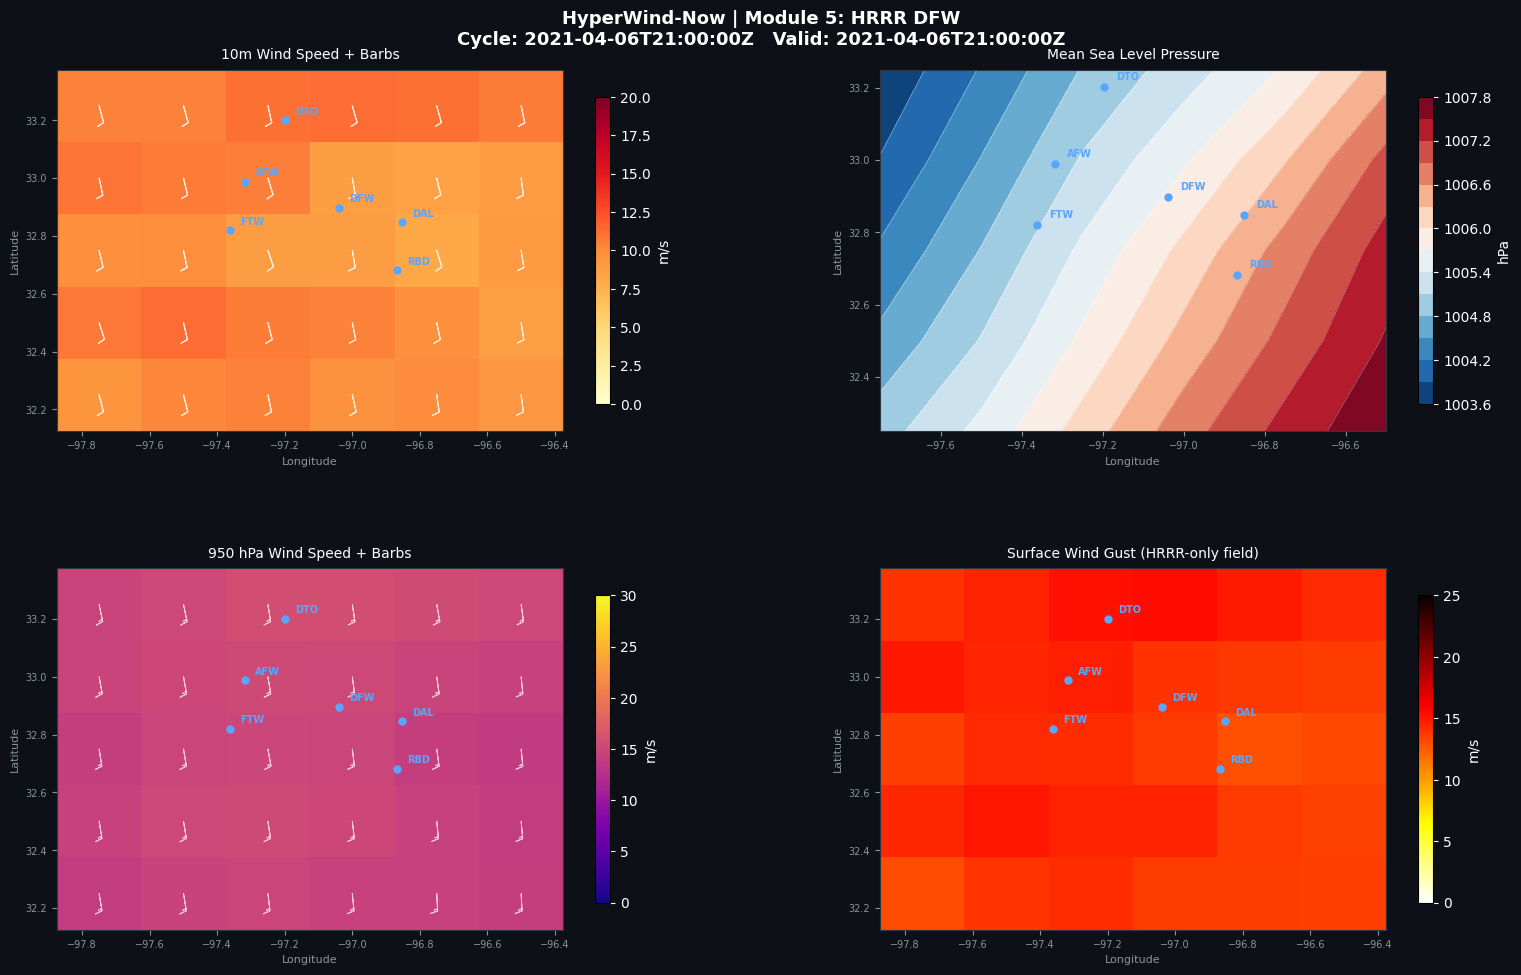

In [37]:
# ── Plot helpers ──────────────────────────────────────────────────────────────

def _style_ax(ax, title, xlabel='Longitude', ylabel='Latitude'):
    ax.set_title(title, color='white', pad=8, fontsize=10)
    ax.set_xlabel(xlabel, color='#8b949e', fontsize=8)
    ax.set_ylabel(ylabel, color='#8b949e', fontsize=8)
    ax.tick_params(colors='#8b949e', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')


def _overlay_stations(ax):
    for name, coords in ASOS_STATIONS.items():
        ax.plot(coords['lon'], coords['lat'], 'o',
                color='#58a6ff', markersize=5, zorder=5)
        ax.text(coords['lon'] + 0.03, coords['lat'] + 0.02, name,
                color='#58a6ff', fontsize=7, fontweight='bold', zorder=6)


def _add_colorbar(fig, ax, im, label):
    cb = plt.colorbar(im, ax=ax, shrink=0.85)
    cb.set_label(label, color='white')
    cb.ax.yaxis.set_tick_params(color='white')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')


def _placeholder(ax, msg):
    ax.text(0.5, 0.5, msg, ha='center', va='center',
            color='#555', fontsize=10, transform=ax.transAxes)


# ── Main plot function ────────────────────────────────────────────────────────

def plot_hrrr_snapshot(nc_path, save_path=None):
    """
    Four-panel diagnostic: wind speed, MSLP, 950 hPa wind, gust.
    All variable accesses use .data_vars to avoid xarray KeyErrors.
    Missing fields show a placeholder panel instead of crashing.
    """
    nc_path = Path(nc_path)
    if not nc_path.exists():
        print(f'File not found: {nc_path} - generating synthetic demo.')
        _plot_synthetic(save_path)
        return

    ds        = xr.open_dataset(nc_path)
    available = set(ds.data_vars)          # always use .data_vars, never ds['x']
    print(f'Variables in NetCDF: {sorted(available)}')

    lats = ds.coords['latitude'].values
    lons = ds.coords['longitude'].values
    LON, LAT = np.meshgrid(lons, lats)

    # Extract all fields safely using .data_vars membership
    u10    = ds['u10'].values[0]  if 'u10'  in available else None
    v10    = ds['v10'].values[0]  if 'v10'  in available else None
    msl    = ds['msl'].values[0] / 100 if 'msl' in available else None  # Pa -> hPa
    gust   = ds['gust'].values[0] if 'gust' in available else None
    spd10  = np.sqrt(u10**2 + v10**2) if (u10 is not None and v10 is not None) else None
    u950   = ds['u'].values[0, -1] if 'u' in available else None
    v950   = ds['v'].values[0, -1] if 'v' in available else None
    spd950 = np.sqrt(u950**2 + v950**2) if (u950 is not None and v950 is not None) else None

    cycle_str = ds.attrs.get('cycle', 'unknown')
    valid_str = ds.attrs.get('valid_time', 'unknown')
    ds.close()

    BG  = '#161b22'
    fig = plt.figure(figsize=(16, 10), facecolor='#0d1117')
    fig.suptitle(
        f'HyperWind-Now | Module 5: HRRR DFW\nCycle: {cycle_str}   Valid: {valid_str}',
        color='white', fontsize=13, fontweight='bold', y=0.98
    )
    gs = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30,
                  left=0.06, right=0.97, top=0.92, bottom=0.06)

    # Panel 1: 10m wind speed
    ax1 = fig.add_subplot(gs[0, 0], facecolor=BG)
    if spd10 is not None:
        im1 = ax1.pcolormesh(LON, LAT, spd10, cmap='YlOrRd', vmin=0, vmax=20, shading='auto')
        ax1.barbs(LON, LAT, u10, v10, length=5, color='white', alpha=0.8, linewidth=0.8)
        _add_colorbar(fig, ax1, im1, 'm/s')
    else:
        _placeholder(ax1, 'u10/v10 not available')
    _overlay_stations(ax1)
    _style_ax(ax1, '10m Wind Speed + Barbs')

    # Panel 2: MSLP
    ax2 = fig.add_subplot(gs[0, 1], facecolor=BG)
    if msl is not None:
        cs2 = ax2.contourf(LON, LAT, msl, levels=15, cmap='RdBu_r')
        ax2.contour(LON, LAT, msl, levels=15, colors='white', linewidths=0.4, alpha=0.5)
        _add_colorbar(fig, ax2, cs2, 'hPa')
    else:
        _placeholder(ax2, 'MSLP not in this fetch\n(MSLMA not matched)')
    _overlay_stations(ax2)
    _style_ax(ax2, 'Mean Sea Level Pressure')

    # Panel 3: 950 hPa wind
    ax3 = fig.add_subplot(gs[1, 0], facecolor=BG)
    if spd950 is not None:
        im3 = ax3.pcolormesh(LON, LAT, spd950, cmap='plasma', vmin=0, vmax=30, shading='auto')
        ax3.barbs(LON, LAT, u950, v950, length=5, color='white', alpha=0.7, linewidth=0.7)
        _add_colorbar(fig, ax3, im3, 'm/s')
        _style_ax(ax3, '950 hPa Wind Speed + Barbs')
    else:
        _placeholder(ax3, 'Pressure-level data not available')
        _style_ax(ax3, '950 hPa Wind')
    _overlay_stations(ax3)

    # Panel 4: Surface gust or speed histogram
    ax4 = fig.add_subplot(gs[1, 1], facecolor=BG)
    if gust is not None:
        im4 = ax4.pcolormesh(LON, LAT, gust, cmap='hot_r', vmin=0, vmax=25, shading='auto')
        _add_colorbar(fig, ax4, im4, 'm/s')
        _overlay_stations(ax4)
        _style_ax(ax4, 'Surface Wind Gust (HRRR-only field)')
    elif spd10 is not None:
        ax4.hist(spd10.ravel(), bins=20, color='#58a6ff', edgecolor='white', linewidth=0.5)
        ax4.tick_params(colors='white')
        for spine in ax4.spines.values(): spine.set_edgecolor('#30363d')
        _style_ax(ax4, '10m Wind Speed Distribution', 'Wind Speed (m/s)', 'Count')
    else:
        _placeholder(ax4, 'No data')
        _style_ax(ax4, 'Surface Wind Gust')

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
        print(f'Saved: {save_path}')
    plt.show()


def _plot_synthetic(save_path):
    np.random.seed(42)
    LON, LAT = np.meshgrid(OUT_LONS, OUT_LATS)
    u   = 8 + 3*np.sin(2*np.pi*(LAT-32.5)) + np.random.randn(*LAT.shape)*0.5
    v   = 2 + 2*np.cos(2*np.pi*(LON+97.0)) + np.random.randn(*LAT.shape)*0.5
    spd = np.sqrt(u**2 + v**2)
    msl = 1013.5 + 2*np.sin(np.pi*(LAT-32.5)) + 1.5*np.cos(np.pi*(LON+97.0))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d1117')
    fig.suptitle('HyperWind-Now | Module 5 Demo (Synthetic)',
                 color='white', fontsize=12, fontweight='bold')
    for ax, data, cmap, label, title in [
        (axes[0], spd, 'YlOrRd', 'm/s', '10m Wind Speed (synthetic)'),
        (axes[1], msl, 'RdBu_r', 'hPa', 'MSLP (synthetic)'),
    ]:
        im = ax.pcolormesh(LON, LAT, data, cmap=cmap, shading='auto')
        ax.barbs(LON, LAT, u, v, length=5, color='white', alpha=0.7)
        _overlay_stations(ax)
        _add_colorbar(fig, ax, im, label)
        ax.set_facecolor('#161b22')
        _style_ax(ax, title)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()


# Run
nc_to_plot = output_path if (output_path and output_path.exists()) else Path('NONEXISTENT')
plot_hrrr_snapshot(nc_to_plot, save_path=RESULTS_DIR / 'module5_hrrr_dfw_snapshot.png')

## 5.10 | Resolution Comparison: ERA5 vs HRRR

Saved: ..\results\module5_resolution_comparison.png


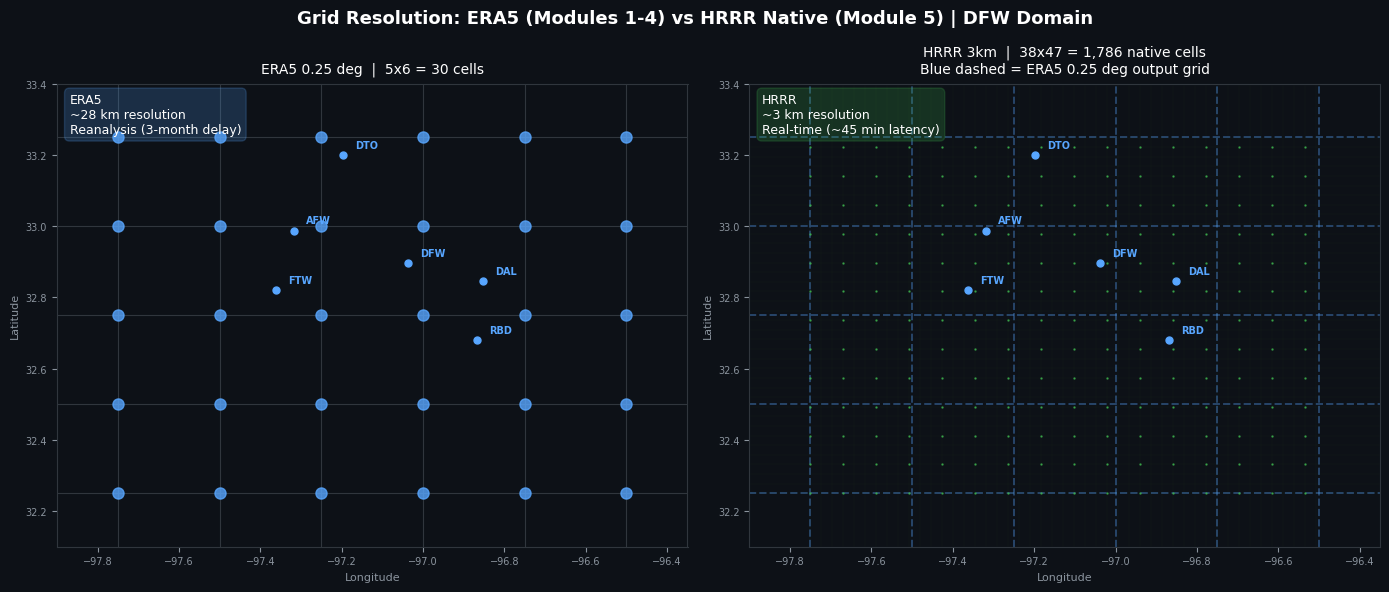

In [38]:
def plot_resolution_comparison():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0d1117')
    fig.suptitle(
        'Grid Resolution: ERA5 (Modules 1-4) vs HRRR Native (Module 5) | DFW Domain',
        color='white', fontsize=13, fontweight='bold'
    )

    # ERA5 panel
    ax0 = axes[0]
    ax0.set_facecolor('#0d1117')
    for lat in OUT_LATS: ax0.axhline(lat, color='#30363d', lw=0.8)
    for lon in OUT_LONS: ax0.axvline(lon, color='#30363d', lw=0.8)
    for lat in OUT_LATS:
        for lon in OUT_LONS:
            ax0.plot(lon, lat, 'o', color='#58a6ff', ms=8, alpha=0.8)
    _overlay_stations(ax0)
    ax0.set_xlim(OUT_LONS[0]-0.15, OUT_LONS[-1]+0.15)
    ax0.set_ylim(OUT_LATS[0]-0.15, OUT_LATS[-1]+0.15)
    ax0.text(0.02, 0.98, 'ERA5\n~28 km resolution\nReanalysis (3-month delay)',
             transform=ax0.transAxes, va='top', color='white', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#58a6ff', alpha=0.2, edgecolor='#58a6ff'))
    _style_ax(ax0, f'ERA5 0.25 deg  |  {len(OUT_LATS)}x{len(OUT_LONS)} = {len(OUT_LATS)*len(OUT_LONS)} cells')

    # HRRR native panel
    ax1 = axes[1]
    ax1.set_facecolor('#0d1117')
    hres   = 0.027
    h_lats = np.arange(OUT_LATS[0], OUT_LATS[-1]+hres/2, hres)
    h_lons = np.arange(OUT_LONS[0], OUT_LONS[-1]+hres/2, hres)
    for lat in h_lats: ax1.axhline(lat, color='#1f2d1f', lw=0.25, alpha=0.5)
    for lon in h_lons: ax1.axvline(lon, color='#1f2d1f', lw=0.25, alpha=0.5)
    for lat in OUT_LATS: ax1.axhline(lat, color='#58a6ff', lw=1.4, alpha=0.35, ls='--')
    for lon in OUT_LONS: ax1.axvline(lon, color='#58a6ff', lw=1.4, alpha=0.35, ls='--')
    for lat in h_lats[::3]:
        for lon in h_lons[::3]:
            ax1.plot(lon, lat, '.', color='#3fb950', ms=1.5, alpha=0.7)
    _overlay_stations(ax1)
    ax1.set_xlim(OUT_LONS[0]-0.15, OUT_LONS[-1]+0.15)
    ax1.set_ylim(OUT_LATS[0]-0.15, OUT_LATS[-1]+0.15)
    n_hrrr = len(h_lats)*len(h_lons)
    ax1.text(0.02, 0.98, 'HRRR\n~3 km resolution\nReal-time (~45 min latency)',
             transform=ax1.transAxes, va='top', color='white', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#3fb950', alpha=0.2, edgecolor='#3fb950'))
    _style_ax(ax1, f'HRRR 3km  |  {len(h_lats)}x{len(h_lons)} = {n_hrrr:,} native cells\n'
              f'Blue dashed = ERA5 0.25 deg output grid')

    plt.tight_layout()
    p = RESULTS_DIR / 'module5_resolution_comparison.png'
    fig.savefig(p, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'Saved: {p}')
    plt.show()


plot_resolution_comparison()

## 5.11 | Architecture Diagram

Saved: ..\results\module5_architecture.png


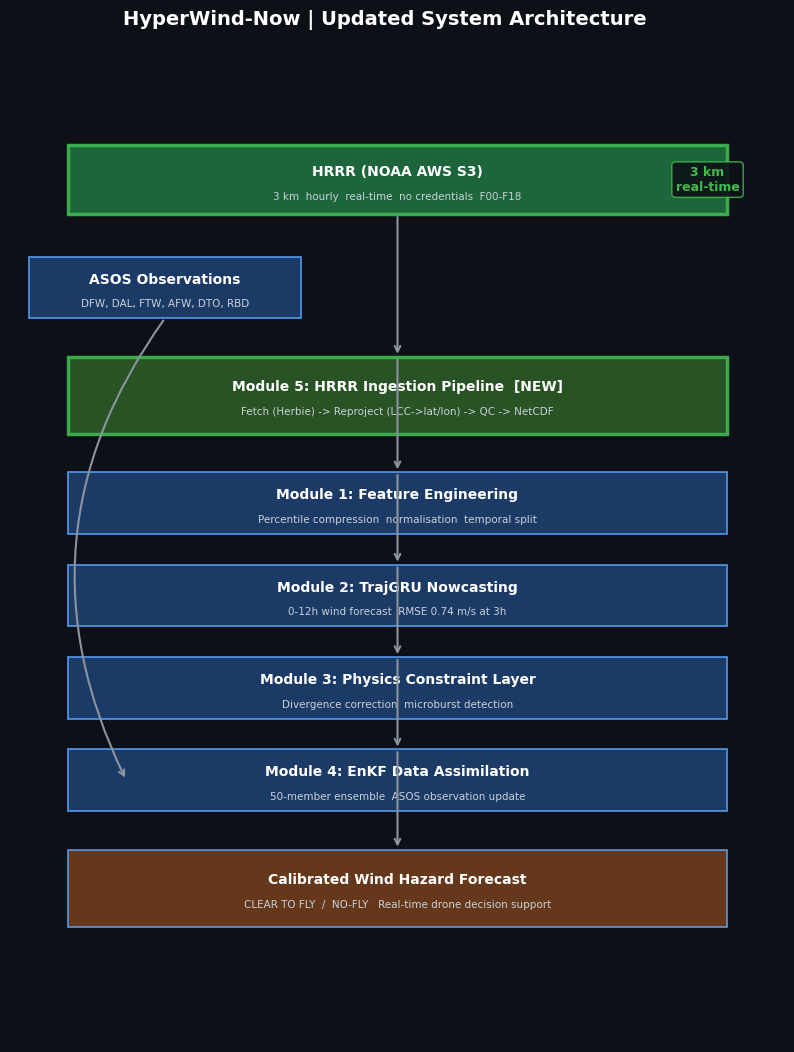

In [39]:
def plot_architecture():
    fig, ax = plt.subplots(figsize=(10, 12), facecolor='#0d1117')
    ax.set_facecolor('#0d1117')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.axis('off')
    fig.suptitle('HyperWind-Now | Updated System Architecture',
                 color='white', fontsize=14, fontweight='bold', y=0.97)

    boxes = [
        (5, 11.2, 8.5, 0.9,
         'HRRR (NOAA AWS S3)',
         '3 km  hourly  real-time  no credentials  F00-F18',
         '#1f6f3f', True),
        (2,  9.8, 3.5, 0.8,
         'ASOS Observations',
         'DFW, DAL, FTW, AFW, DTO, RBD',
         '#1d3f6f', False),
        (5,  8.4, 8.5, 1.0,
         'Module 5: HRRR Ingestion Pipeline  [NEW]',
         'Fetch (Herbie) -> Reproject (LCC->lat/lon) -> QC -> NetCDF',
         '#2d5a27', True),
        (5,  7.0, 8.5, 0.8,
         'Module 1: Feature Engineering',
         'Percentile compression  normalisation  temporal split',
         '#1d3f6f', False),
        (5,  5.8, 8.5, 0.8,
         'Module 2: TrajGRU Nowcasting',
         '0-12h wind forecast  RMSE 0.74 m/s at 3h',
         '#1d3f6f', False),
        (5,  4.6, 8.5, 0.8,
         'Module 3: Physics Constraint Layer',
         'Divergence correction  microburst detection',
         '#1d3f6f', False),
        (5,  3.4, 8.5, 0.8,
         'Module 4: EnKF Data Assimilation',
         '50-member ensemble  ASOS observation update',
         '#1d3f6f', False),
        (5,  2.0, 8.5, 1.0,
         'Calibrated Wind Hazard Forecast',
         'CLEAR TO FLY  /  NO-FLY   Real-time drone decision support',
         '#6f3d1d', False),
    ]

    for xc, yc, w, h, label, sub, color, is_new in boxes:
        rect = plt.Rectangle(
            (xc-w/2, yc-h/2), w, h,
            facecolor=color,
            edgecolor='#3fb950' if is_new else '#58a6ff',
            linewidth=2.5 if is_new else 1.2,
            alpha=0.9, zorder=2
        )
        ax.add_patch(rect)
        ax.text(xc, yc+0.10, label, ha='center', va='center',
                color='white', fontsize=10, fontweight='bold', zorder=3)
        ax.text(xc, yc-0.22, sub, ha='center', va='center',
                color='#c9d1d9', fontsize=7.5, zorder=3)

    kw = dict(arrowstyle='->', color='#8b949e', lw=1.5)
    for y1, y2 in [(10.75, 8.9), (8.9, 7.4), (7.4, 6.2), (6.2, 5.0), (5.0, 3.8), (3.8, 2.5)]:
        ax.annotate('', xy=(5, y2), xytext=(5, y1), arrowprops=dict(**kw))
    ax.annotate('', xy=(1.5, 3.4), xytext=(2, 9.4),
                arrowprops=dict(**kw, connectionstyle='arc3,rad=0.3'))
    ax.text(9.0, 11.2, '3 km\nreal-time', ha='center', va='center',
            color='#3fb950', fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0d1117',
                      edgecolor='#3fb950', alpha=0.9))

    p = RESULTS_DIR / 'module5_architecture.png'
    fig.savefig(p, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'Saved: {p}')
    plt.show()


plot_architecture()

## 5.12 | Integration Guide

### Drop-in replacement for ERA5

```python
# module1_data_pipeline.ipynb - change one line:

# BEFORE
era5_ds = load_era5(start='2021-04-06', end='2021-04-06')

# AFTER
from module5_hrrr_ingestion import HRRRPipeline
nc_path  = HRRRPipeline().run_latest()
era5_ds  = xr.open_dataset(nc_path)   # ERA5-schema compatible
```

### ERA5 vs HRRR comparison

| | ERA5 (Modules 1-4) | HRRR (Module 5) |
|---|---|---|
| Resolution | ~28 km | ~3 km native to 0.25 deg output |
| Update cycle | Monthly reanalysis | Hourly real-time |
| Availability | 3-5 month delay | ~45 min latency |
| Radar DA | No | Yes (15-min cycle) |
| Wind gust | No | Yes (GUST:surface) |
| Credentials | CDS API key | None |
| Operational | No | Yes |

### Variables fetched

| Variable | GRIB search | Output name |
|---|---|---|
| 10m U-wind | `:UGRD:10 m above ground:` | `u10` |
| 10m V-wind | `:VGRD:10 m above ground:` | `v10` |
| MSLP | `:MSLMA:` | `msl` |
| Surface gust | `:GUST:surface:` | `gust` |
| 1000/975/950 hPa U/V | `:UGRD/VGRD:NNN mb:` | `u`, `v` (level dim) |

### Installation
```bash
pip install herbie-data cfgrib scipy pyproj eccodes
```

---
**Author:** Emmanuel Ibekwe | ibekwemmanuel@gmail.com